# **Meshlands - Fluxes**
This notebook displays important resources to study the radiative budget that balances the global climate of Meshlands.\
The plots are divided into several sections:
- Surface Latent Heat Flux
- Surface Sensible Heat Flux
- Net Longwave Flux at Surface
- Net Longwave Flux at TOA
- Solar Flux at Surface
- Solar Flux at TOA
- Poleward Energy Transport (useful to understand how the climate is balanced by the atmospheric heat transport)
- Albedo (high impact on climate because of the huge glaciation that exists in our simulations)

## **Initial Set Up-related**

### Imports

In [1]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob
import time

########## Cartopy ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## SciPy ##########
from scipy import integrate
import scipy.ndimage as ndi

########## Xarray ##########
import xarray as xr

### Function Definitions

In [2]:
def quick_map(mapdata,lat,lon,mesh,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,close=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):
    '''
    Creates a new local mapping function that does not use a basemap
    '''
    fig = plt.figure(figsize=(15,15))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects coordinates to plot the coastlines
    xc_cyc = np.concatenate([mesh["xc"], mesh["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh["yc"], mesh["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh["mask"], mesh["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons,lat,cyclic_data,transform=ccrs.PlateCarree())
    
    # If a cmap (colour map) is specified, copy and use it
    # Else, copy and use the viridis cmap
    if cmap:
        plt.set_cmap(copy(cmap))
    else:
        plt.set_cmap(copy(plt.cm.viridis))

    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=16,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        plt.cm.ScalarMappable.set_clim(cs,vmin = clim[0],vmax = clim[1])

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=14) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=14)

    # Sets cm to the cmap
    cm = plt.get_cmap()
   
    # Overall: adds hatching for significance
    # If a p-value is specified, add 
    if p:

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_sig, cyclic_lons = add_cyclic_point(sigmask,coord=lon)

        # Creates a meshgrid using cyclic longitude and latitude coordinates
        CLN, CLT = np.meshgrid(cyclic_lons,lat)

        # Only puts the hatches where the sigmask is >0.5
        sigmask = np.where(cyclic_sig>p,1.0,np.nan)
        sigmask2 = np.ma.masked_where(cyclic_sig > p, sigmask)

        # Masks out insignificant latitude data
        lat_sig = np.ma.masked_where(cyclic_sig>p,CLT)

        # Masks out NaN latitude data
        lat_sig = np.ma.masked_where(np.isnan(cyclic_sig),lat_sig)

        # Masks out insignificant longitude data
        lon_sig = np.ma.masked_where(cyclic_sig>p,CLN)

        # Masks out NaN longitude data
        lon_sig = np.ma.masked_where(np.isnan(cyclic_sig),lon_sig)

        # Scatters markers
        hatch = ax.scatter(lon_sig,lat_sig,s=sigmask2,marker='x',#s=2,
                           c=[0.6, 0.6, 0.6],alpha=0.8,transform=ccrs.PlateCarree(),)

    # Add points at the center of each ocean group
    ocean_mask = (mesh['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers = []
    lat_centers = []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        # Interpolate coordinates assuming regular grid
        dlon = mesh['xc'][0, 1] - mesh['xc'][0, 0]
        dlat = mesh['yc'][1, 0] - mesh['yc'][0, 0]
        lon_center = mesh['xc'][0, 0] + x * dlon
        lat_center = mesh['yc'][0, 0] + y * dlat
        lon_centers.append(lon_center)
        lat_centers.append(lat_center)
    ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=5, transform=ccrs.PlateCarree())
    
    # Sets the alpha value
    ax.patch.set_alpha(0.0)

    # Add a line at the bottom of the plot to draw the separation with the following plot
    line = plt.Line2D([0.1, 1], [0.12, 0.12], transform=fig.transFigure, color='black')
    fig.add_artist(line)
    
    # If show is specified, show the plot
    if show:
        plt.show()

    # If filepath is specified, save the figured to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    if close:
        plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

############

def quick_trop(mapdata,lat,lon,mesh,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,close=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):
    '''
    Variation of the quick_map function to only observe Tropics and Subtropics
    '''
    fig = plt.figure(figsize=(15,15))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects coordinates to plot the coastlines
    xc_cyc = np.concatenate([mesh["xc"], mesh["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh["yc"], mesh["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh["mask"], mesh["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be focused over Subtropics
    ax.set_extent([-170, -90, -30, 30], crs=ccrs.PlateCarree())

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons,lat,cyclic_data,transform=ccrs.PlateCarree())
    
    # If a cmap (colour map) is specified, copy and use it
    # Else, copy and use the viridis cmap
    if cmap:
        plt.set_cmap(copy(cmap))
    else:
        plt.set_cmap(copy(plt.cm.viridis))

    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=16,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        plt.cm.ScalarMappable.set_clim(cs,vmin = clim[0],vmax = clim[1])

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.05, shrink=0.9)
    cbar.ax.tick_params(labelsize=30) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=50)

    # Sets cm to the cmap
    cm = plt.get_cmap()

    # Add points at the center of each ocean group
    ocean_mask = (mesh['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers = []
    lat_centers = []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        # Interpolate coordinates assuming regular grid
        dlon = mesh['xc'][0, 1] - mesh['xc'][0, 0]
        dlat = mesh['yc'][1, 0] - mesh['yc'][0, 0]
        lon_center = mesh['xc'][0, 0] + x * dlon
        lat_center = mesh['yc'][0, 0] + y * dlat
        lon_centers.append(lon_center)
        lat_centers.append(lat_center)
    ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=5, transform=ccrs.PlateCarree())
    
    # If show is specified, show the plot
    if show:
        plt.show()

    # If filepath is specified, save the figured to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    if close:
        plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

##########

def quick_trop_large(mapdata,lat,lon,mesh,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,close=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):
    '''
    Variation of the quick_trop function to conserve the full longitudinal extent of the planet
    '''
    fig = plt.figure(figsize=(15,15))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects coordinates to plot the coastlines
    xc_cyc = np.concatenate([mesh["xc"], mesh["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh["yc"], mesh["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh["mask"], mesh["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_extent([-180, 180, -30, 30], crs=ccrs.PlateCarree())

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons,lat,cyclic_data,transform=ccrs.PlateCarree())
    
    # If a cmap (colour map) is specified, copy and use it
    # Else, copy and use the viridis cmap
    if cmap:
        plt.set_cmap(copy(cmap))
    else:
        plt.set_cmap(copy(plt.cm.viridis))

    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=16,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        plt.cm.ScalarMappable.set_clim(cs,vmin = clim[0],vmax = clim[1])

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.05, shrink=0.9)
    cbar.ax.tick_params(labelsize=15) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=20)

    # Sets cm to the cmap
    cm = plt.get_cmap()

    # Add points at the center of each ocean group
    ocean_mask = (mesh['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers = []
    lat_centers = []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        # Interpolate coordinates assuming regular grid
        dlon = mesh['xc'][0, 1] - mesh['xc'][0, 0]
        dlat = mesh['yc'][1, 0] - mesh['yc'][0, 0]
        lon_center = mesh['xc'][0, 0] + x * dlon
        lat_center = mesh['yc'][0, 0] + y * dlat
        lon_centers.append(lon_center)
        lat_centers.append(lat_center)
    ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=5, transform=ccrs.PlateCarree())
    
    # If show is specified, show the plot
    if show:
        plt.show()

    # If filepath is specified, save the figured to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    if close:
        plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

###############

def mean(ds_case,mask,var):
    '''
    Calculates the global, ocean and land mean of a given variable for a given configuration.

    Args:
        ds_case (xarray): dictionary containing lat and lon dimensions.
        mask (list): representation of continental distribution, with value 1 if land and value 0 if ocean.
        var (str): name of the variable that needs to be averaged.

    Returns:
        gm (float OR array): global mean (can be an array if ds_case contains other dimensions).
        lm (float OR array): land mean (can be an array if ds_case contains other dimensions).
        om (float OR array): ocean mean (can be an array if ds_case contains other dimensions).
    '''

    # Collects the datas to plot the surface temperature
    mapdata = (ds_case[var].mean('year'))
    
    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case[var].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon')).values

    # Defines a land timeseries where the land mask is present
    land = mapdata.where(mask == 1)

    # Defines an ocean timeseries where the land mask is not present (i.e. just ocean/water)
    ocean = mapdata.where(mask != 1)

    # Mean Land
    lm = land.weighted(weights).mean(('lat', 'lon')).values

    # Mean Ocean
    om = ocean.weighted(weights).mean(('lat', 'lon')).values

    return gm, lm, om

############
    
def inferred_heat_transport( energy_in, lat_deg ):
    '''
    Returns the inferred heat transport (in PW) by integrating the net energy imbalance from pole to pole.

    Args:
        energy_in (xarray): net radiative flux that enters the atmosphere (longitude-averaged)
        lat_deg (xarray): latitude values of the dictionary

    Returns:
        (xarray): total northward heat transport (longitude-averaged)
    '''
    
    lat_rad = np.deg2rad( lat_deg )
    R_earth = 6.371e6
    
    return (1E-15 * 2 * np.math.pi * R_earth**2 * integrate.cumtrapz( np.cos(lat_rad)*energy_in, x=lat_rad, initial=0.))

### Path Definitions

In [3]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [4]:
# Creates a list of atmospheric variables
atm_vars = ['FLDS','FLNS','FLNSC','FLNT','FLNTC','FSDS','FSDSC','FSNS','FSNSC','FSNT','LHFLX','SHFLX']

### Dictionary Definitions

In [5]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [6]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Surface Latent Heat Flux**

Since a large part of the world is frozen above the Tropics, the observation is mainly made over a small latitude ranges.
The plot shows the surface latent heat flux (corresponding to the evaporation) for all patch sizes.

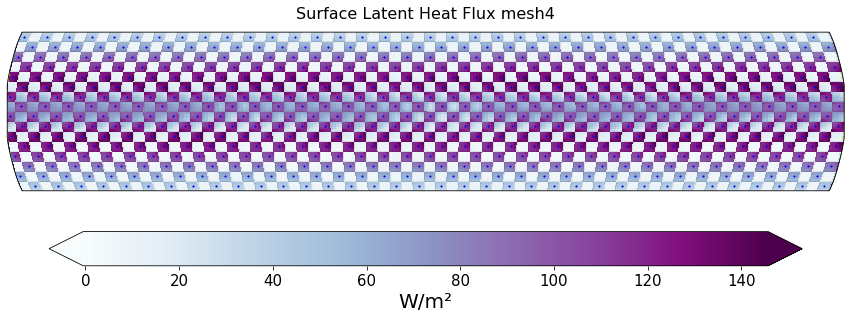

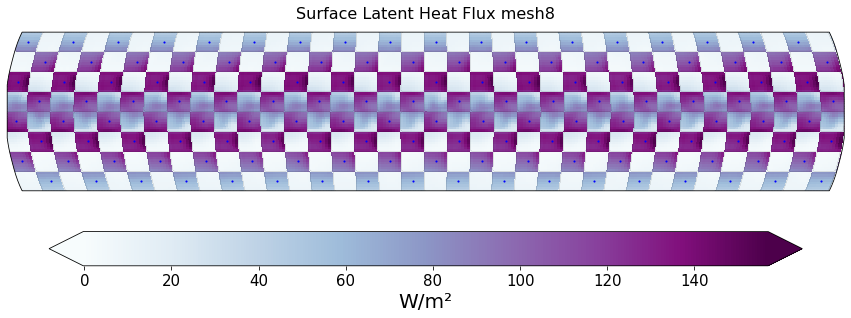

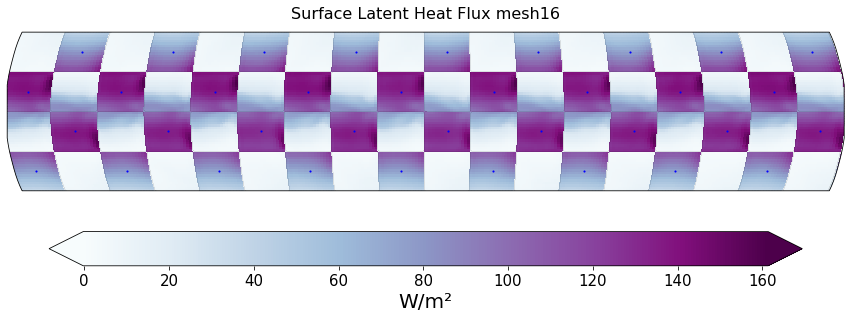

In [7]:
# Overall: creates a map plot of each of the simulation cases, using the quick_trop_large function

for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['LHFLX'].mean('year')

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values

    # Use the mean function
    gm, lm, om = mean(ds_case, mask, 'LHFLX')
    
    # Sets the plot's title
    ttl = 'Surface Latent Heat Flux %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('BuPu')

    # Uses the quick_trop_large function (defined previously) to create the plot
    fig, ax, cs, cbar, cm = quick_trop_large(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='W/m²',
              cmap=cmap,clim=None,
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')

    plt.show()
    plt.close()

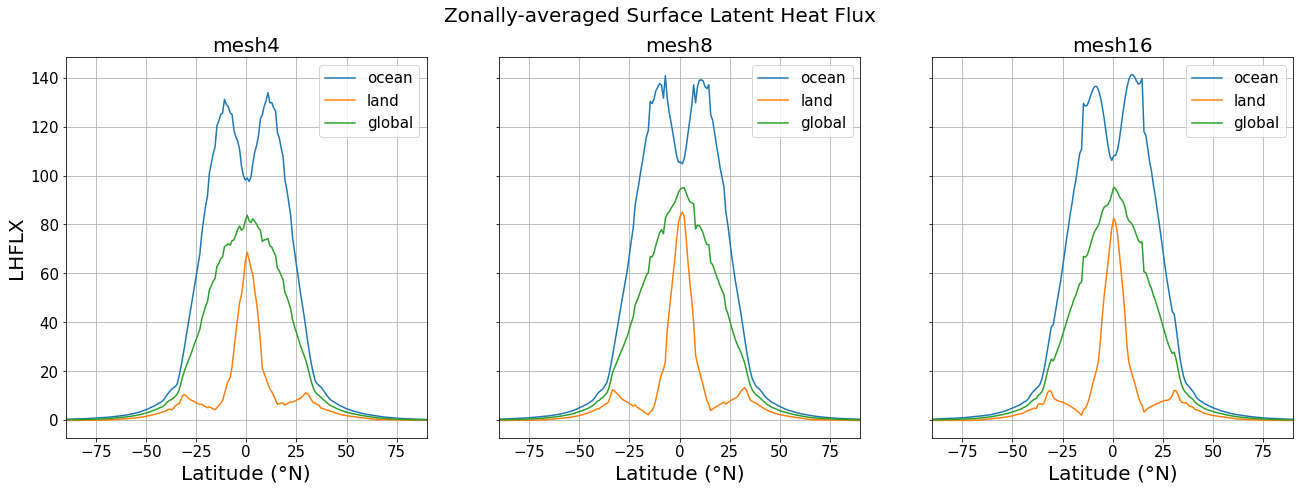

In [8]:
# Overall: plots separately the zonally averaged surface latent heat flux for all patch sizes

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['LHFLX'].mean('year')

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    # Plots the different mapdata computed (ocean mean, land mean, and global mean)
    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case,fontsize=20)
    axes[i].set_xlabel('Latitude (°N)',fontsize=20)
    axes[i].set_xlim([-90,90])
    axes[i].tick_params(labelsize=15)
    axes[i].legend(fontsize=15)
    axes[i].grid()

axes[0].set_ylabel('LHFLX',fontsize=20)

plt.suptitle('Zonally-averaged Surface Latent Heat Flux', fontsize=20)

plt.show()
plt.close()

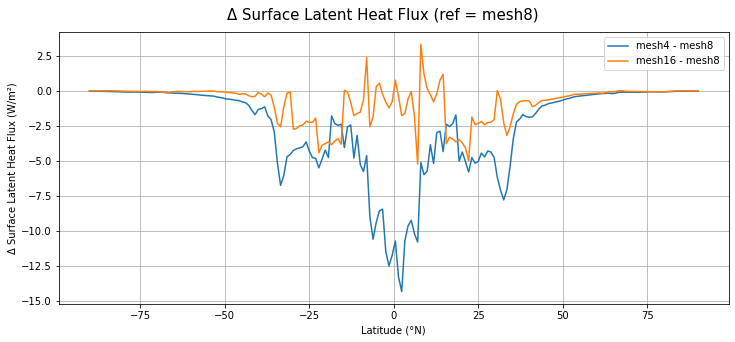

In [9]:
# Overall: shows the delta between all meshes in terms of zonally averaged surface latent heat flux

plt.figure(figsize=(12,5))

# Groups the case's atmospheric time series dictionary by year, calculates the mean
ds_mesh4 = ts_dict_atm['mesh4'].groupby('time.year').mean('time').mean('lon')
ds_mesh16 = ts_dict_atm['mesh16'].groupby('time.year').mean('time').mean('lon')

# Groups the reference's atmospheric time series dictionary by year, calculates the mean
ds_mesh8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time').mean('lon')

# Finds the difference between the case's data and the reference's data
mapdata4 = (ds_mesh4['LHFLX'].mean('year')) - (ds_mesh8['LHFLX'].mean('year'))
mapdata16 = (ds_mesh16['LHFLX'].mean('year')) - (ds_mesh8['LHFLX'].mean('year'))

# Draws the plots
plt.plot(mapdata4.lat,mapdata4,label='mesh4 - mesh8')
plt.plot(mapdata16.lat,mapdata16,label='mesh16 - mesh8')

# Sets the figure's title
plt.suptitle('Δ Surface Latent Heat Flux (ref = mesh8)', fontsize=15, y=0.95)

plt.xlabel('Latitude (°N)')
plt.ylabel('Δ Surface Latent Heat Flux (W/m²)')
plt.legend()
plt.grid()

plt.show()
plt.close()

# **Surface Sensible Heat Flux**

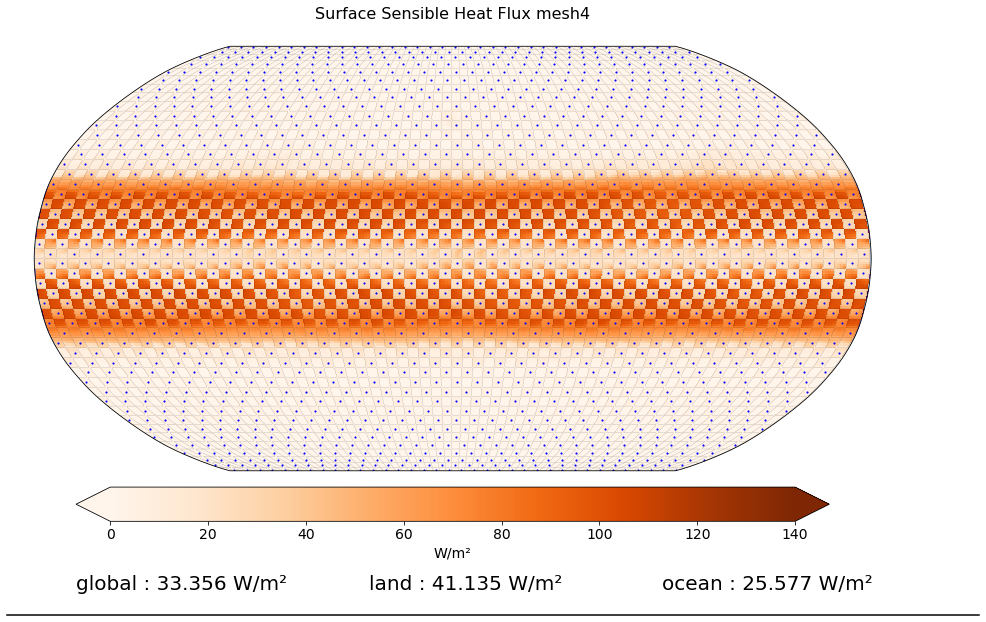

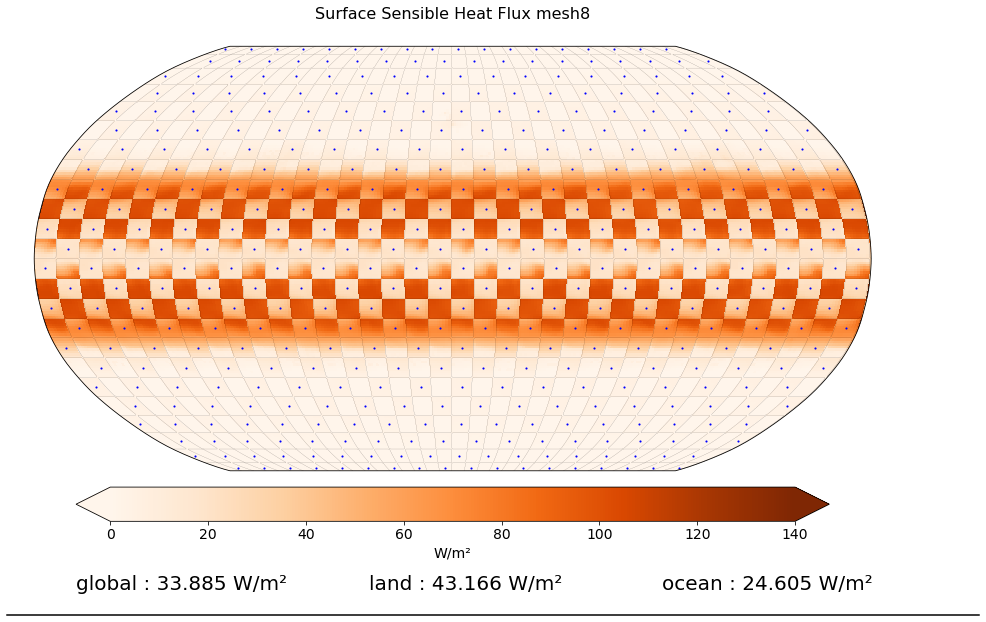

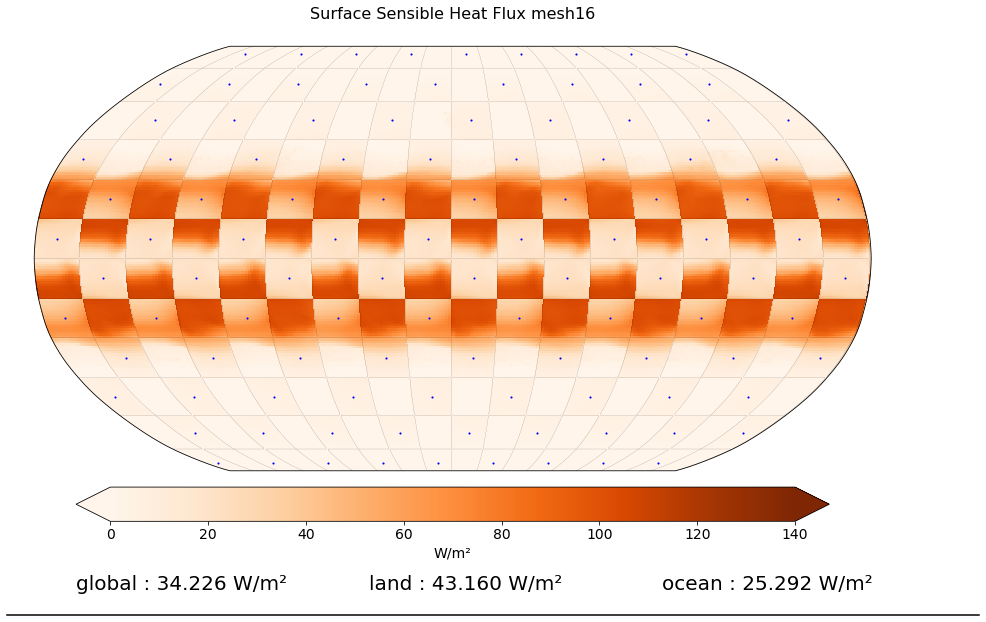

In [10]:
# Overall: creates a map plot of each of the simulation cases, using the quick_map function

for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = (ds_case['SHFLX'].mean('year'))

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values

    # Use the mean function
    gm, lm, om = mean(ds_case, mask, 'SHFLX')
    
    # Sets the plot's title
    ttl = 'Surface Sensible Heat Flux %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('Oranges')

    fig, ax, cs, cbar, cm = quick_map(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='W/m²',
              cmap=cmap,clim=[0,140.],
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')

    # Annotates the subplot with the global mean, land mean, and ocean mean
    ax.text(0.05, -0.28, 'global : %1.3f W/m²'%gm, transform=ax.transAxes, fontsize=20)
    ax.text(0.4, -0.28, 'land : %1.3f W/m²'%lm, transform=ax.transAxes, fontsize=20)
    ax.text(0.75, -0.28, 'ocean : %1.3f W/m²'%om, transform=ax.transAxes, fontsize=20)

    plt.show()
    plt.close()

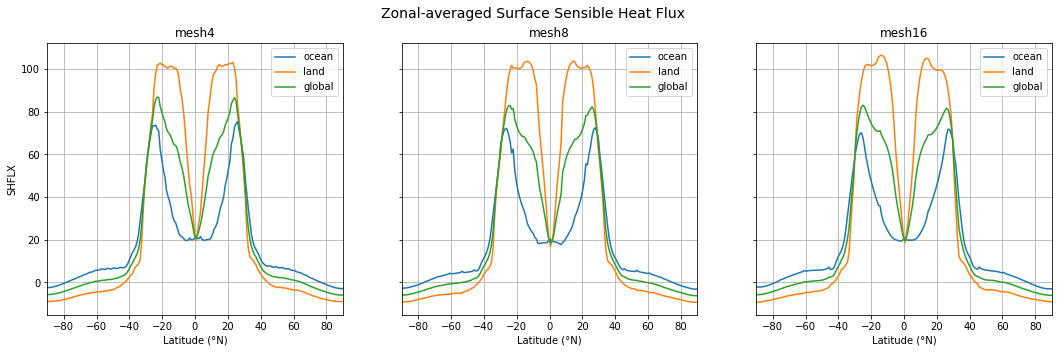

In [11]:
# Overall: plots separately the zonally averaged surface sensible heat flux for all patch sizes

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['SHFLX'].mean('year')
    
    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].set_xlim([-90,90])
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('SHFLX')

plt.suptitle('Zonal-averaged Surface Sensible Heat Flux', fontsize=14)

plt.show()
plt.close()

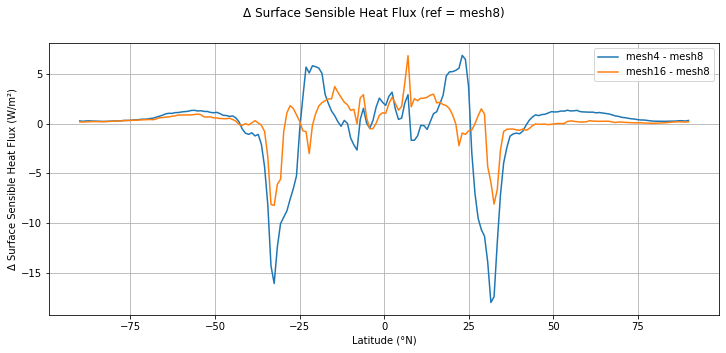

In [12]:
# Overall: shows the delta between all meshes in terms of zonally averaged surface sensible heat flux

plt.figure(figsize=(12,5))

# Groups the case's atmospheric time series dictionary by year, calculates the mean
ds_mesh4 = ts_dict_atm['mesh4'].groupby('time.year').mean('time').mean('lon')
ds_mesh16 = ts_dict_atm['mesh16'].groupby('time.year').mean('time').mean('lon')

# Groups the reference's atmospheric time series dictionary by year, calculates the mean
ds_mesh8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time').mean('lon')

# Finds the difference between the case's data and the reference's data
mapdata4 = (ds_mesh4['SHFLX'].mean('year')) - (ds_mesh8['SHFLX'].mean('year'))
mapdata16 = (ds_mesh16['SHFLX'].mean('year')) - (ds_mesh8['SHFLX'].mean('year'))

# Draws the plots
plt.plot(mapdata4.lat,mapdata4,label='mesh4 - mesh8')
plt.plot(mapdata16.lat,mapdata16,label='mesh16 - mesh8')

# Sets the figure's title
plt.suptitle('Δ Surface Sensible Heat Flux (ref = mesh8)')

plt.xlabel('Latitude (°N)')
plt.ylabel('Δ Surface Sensible Heat Flux (W/m²)')
plt.legend()
plt.grid()

plt.show()
plt.close()

# **Net longwave flux at surface**

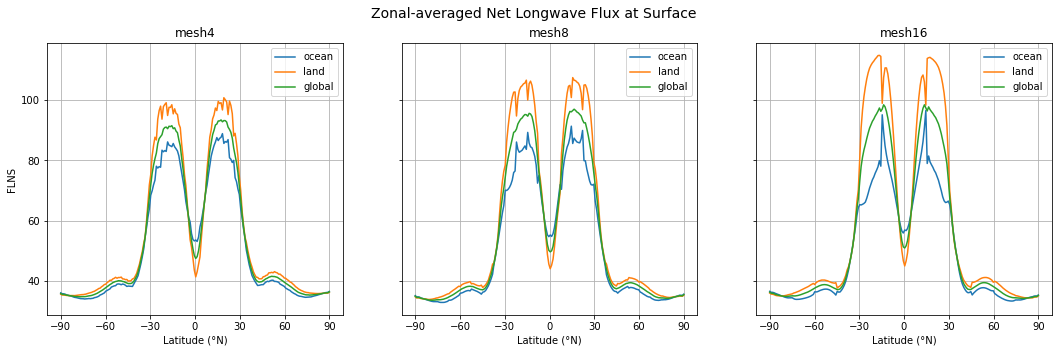

In [13]:
# Overall: plots separately the zonally averaged net longwave flux at surface for all patch sizes

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['FLNS'].mean('year')

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].set_xticks([-90,-60,-30,0,30,60,90])
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('FLNS')

plt.suptitle('Zonal-averaged Net Longwave Flux at Surface', fontsize=14)

plt.show()
plt.close()

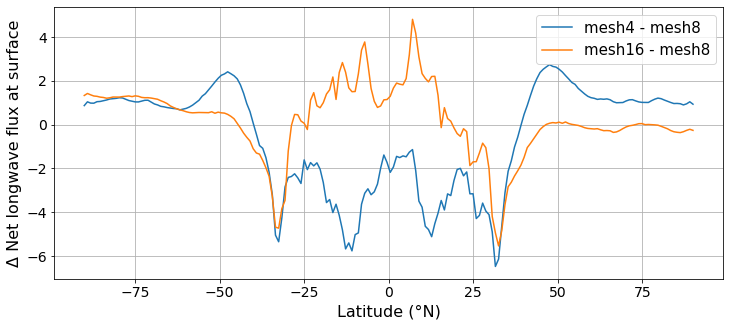

In [14]:
# Overall: shows the delta between all meshes in terms of zonally averaged net longwave flux at the surface

plt.figure(figsize=(12,5))

# Groups the reference's atmospheric time series dictionary by year, calculates the mean
ds_8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds_8['FLNS'].mean('year').mean('lon')

for case in ['mesh4','mesh16'] :

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the difference between current case's net longwave flux at surface and the reference's value
    mapdata = ds_case['FLNS'].mean('year').mean('lon') - ref
    
    plt.plot(mapdata.lat,mapdata,label=f'{case} - mesh8')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Δ Net longwave flux at surface',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)

plt.show()
plt.close()

# **Net longwave flux at top of model**

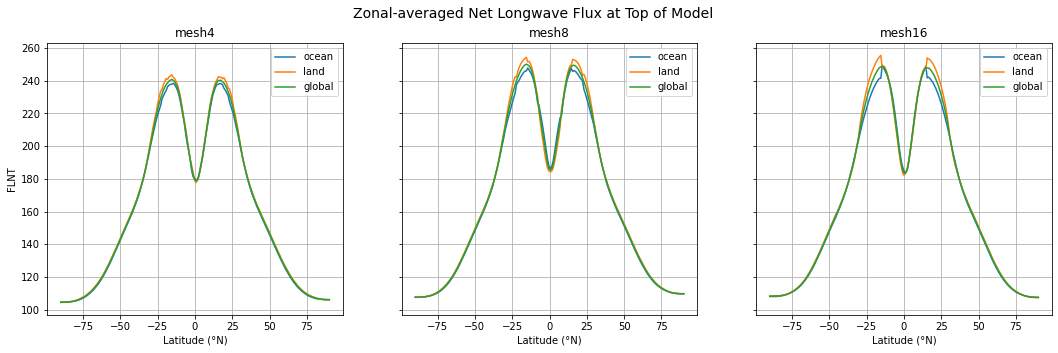

In [15]:
# Overall: plots separately the zonally averaged net longwave flux at TOA for all patch sizes

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(config) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['FLNT'].mean('year')
    
    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('FLNT')

plt.suptitle('Zonal-averaged Net Longwave Flux at Top of Model', fontsize=14)

plt.show()
plt.close()

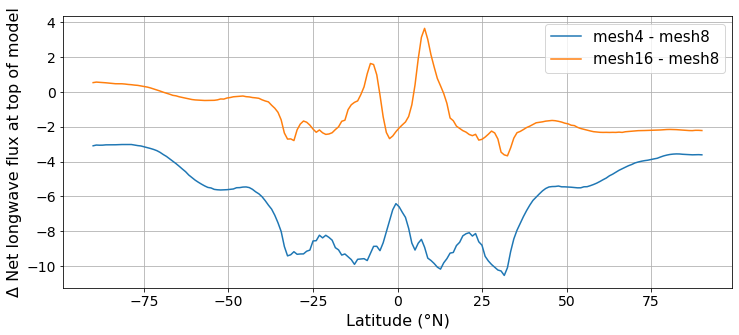

In [16]:
# Overall: shows the delta between all meshes in terms of zonally averaged net longwave flux at TOA

plt.figure(figsize=(12,5))

# Groups the reference's atmospheric time series dictionary by year, calculates the mean
ds_8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds_8['FLNT'].mean('year').mean('lon')

for case in ['mesh4','mesh16'] :

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the difference between current case's net longwave flux at TOA and the reference's value
    mapdata = ds_case['FLNT'].mean('year').mean('lon') - ref
    
    plt.plot(mapdata.lat,mapdata,label=f'{case} - mesh8')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Δ Net longwave flux at top of model',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)

plt.show()
plt.close()

# **Net solar flux at surface**

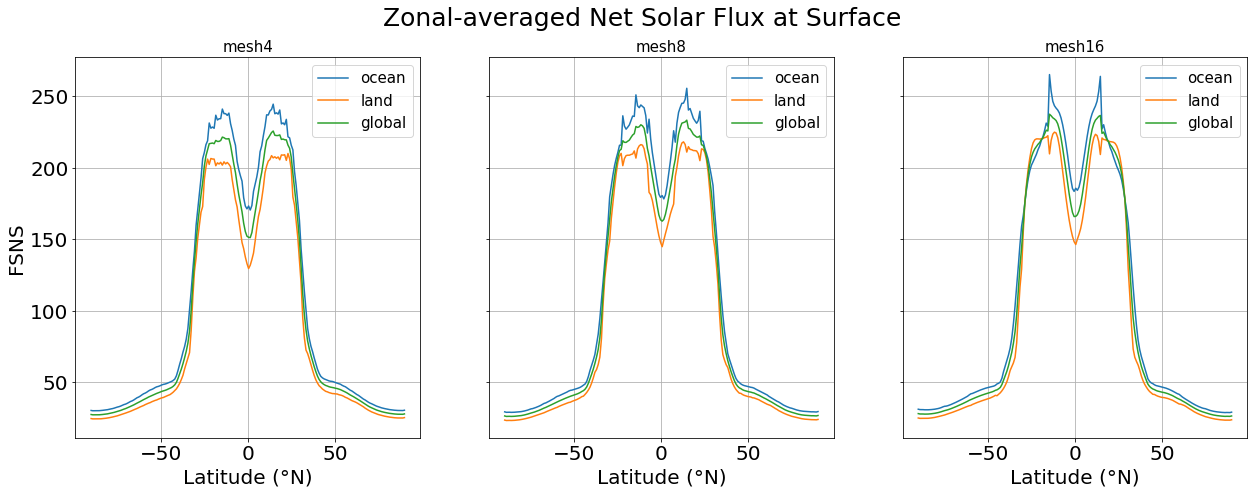

In [17]:
# Overall: plots separately the zonally averaged net solar flux at the surface for all patch sizes

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=True)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['FSNS'].mean('year')

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case,fontsize=15)
    axes[i].set_xlabel('Latitude (°N)',fontsize=20)
    axes[i].tick_params(axis='both', labelsize=20)
    axes[i].legend(fontsize=15)
    axes[i].grid()

axes[0].set_ylabel('FSNS',fontsize=20)

plt.suptitle('Zonal-averaged Net Solar Flux at Surface', fontsize=25)

plt.show()
plt.close()

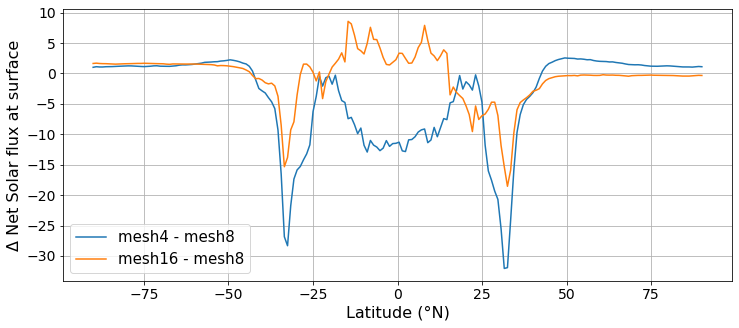

In [18]:
# Overall: shows the delta between all meshes in terms of zonally averaged net solar flux at the surface

plt.figure(figsize=(12,5))

# Groups the reference's atmospheric time series dictionary by year, calculates the mean
ds_8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds_8['FSNS'].mean('year').mean('lon')

for case in ['mesh4','mesh16'] :

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the difference between current case's net solar flux at the surface and the reference's value
    mapdata = ds_case['FSNS'].mean('year').mean('lon') - ref
    
    plt.plot(mapdata.lat,mapdata,label=f'{case} - mesh8')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Δ Net Solar flux at surface',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)
plt.show()
plt.close()

# **Net solar flux at top of model**

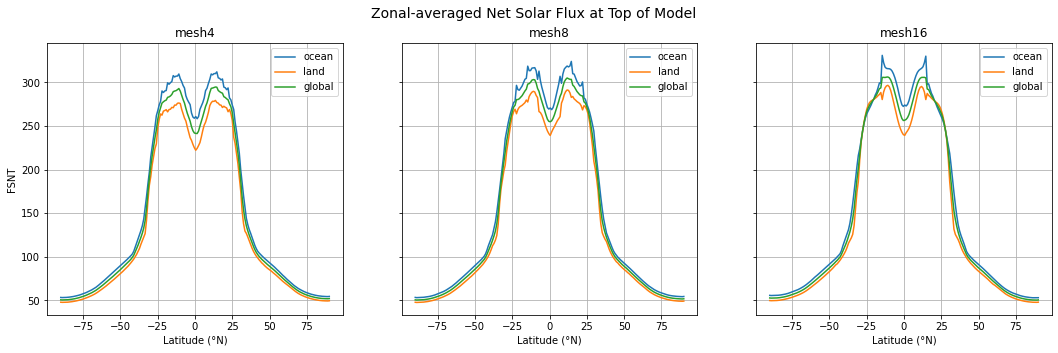

In [19]:
# Overall: plots separately the zonally averaged net solar flux at TOA for all patch sizes

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for (i,case) in enumerate(config) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = ds_case['FSNT'].mean('year')
    
    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    ocn = mapdata.where(mask == 0).mean('lon')
    lnd = mapdata.where(mask == 1).mean('lon')

    axes[i].plot(ocn.lat,ocn,label='ocean')
    axes[i].plot(lnd.lat,lnd,label='land')
    axes[i].plot(mapdata.lat,mapdata.mean('lon'),label='global')

    axes[i].set_title(case)
    axes[i].set_xlabel('Latitude (°N)')
    axes[i].legend()
    axes[i].grid()

axes[0].set_ylabel('FSNT')

plt.suptitle('Zonal-averaged Net Solar Flux at Top of Model', fontsize=14)

plt.show()
plt.close()

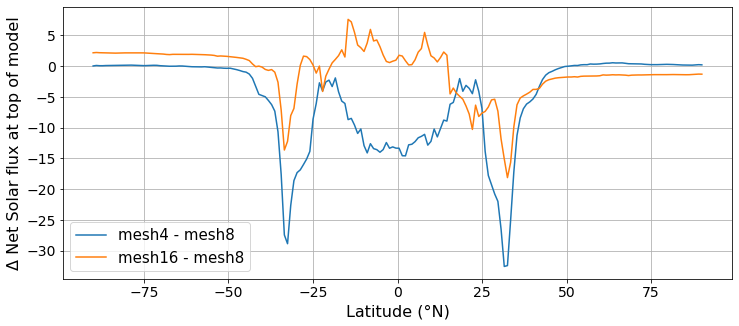

In [20]:
# Overall: shows the delta between all meshes in terms of zonally averaged net solar flux at TOA

plt.figure(figsize=(12,5))

# Groups the reference's atmospheric time series dictionary by year, calculates the mean
ds_8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = ds_8['FSNT'].mean('year').mean('lon')

for case in ['mesh4','mesh16'] :

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the difference between current case's net solar flux at TOA and the reference's value
    mapdata = ds_case['FSNT'].mean('year').mean('lon') - ref
    
    plt.plot(mapdata.lat,mapdata,label=f'{case} - mesh8')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Δ Net Solar flux at top of model',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)

plt.show()
plt.close()

# **Polewards Energy Transport**

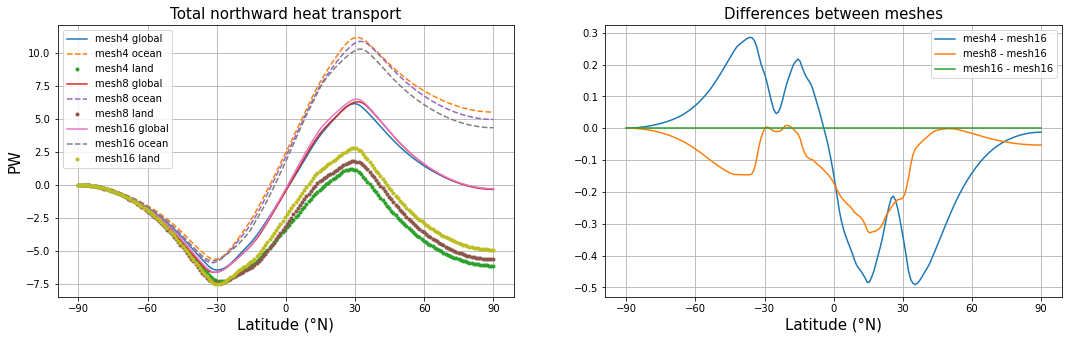

In [21]:
# Overall: plots simultaneously the northward heat transport for all meshes and the differences between them

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Creates empty dictionaries to contain the land values, the ocean values, and the global values
transport_glo_dict = {}
transport_ocn_dict = {}
transport_lnd_dict = {}

for case in config :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    lat_cesm = ds_case.lat
    
    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values

    # Collects all the variables needed to calculate the heat transport
    LHFLX = ds_case['LHFLX'].mean('year')
    SHFLX = ds_case['SHFLX'].mean('year')
    FLNS = ds_case['FLNS'].mean('year')
    FSNS = ds_case['FSNS'].mean('year')
    FLNT = ds_case['FLNT'].mean('year')
    FSNT = ds_case['FSNT'].mean('year')

    net_in_bot = LHFLX + SHFLX + FLNS - FSNS
    net_out_top = FLNT - FSNT
    energy_in = net_in_bot - net_out_top

    # Uses the inferred_heat_transport function and adds the result to the dedicated dictionaries
    transport_glo_dict[case] = inferred_heat_transport(energy_in.mean('lon'), lat_cesm)
    transport_ocn_dict[case] = inferred_heat_transport(energy_in.where(mask==0).mean('lon'), lat_cesm)
    transport_lnd_dict[case] = inferred_heat_transport(energy_in.where(mask==1).mean('lon'), lat_cesm)

# Creates a dictionary to contain the reference's configuration
ref_glo = transport_glo_dict['mesh16']
ref_ocn = transport_ocn_dict['mesh16']

# Plots separately the absolute values and the differences between them
for case in config :
    ax1.plot(lat_cesm, transport_glo_dict[case], label=f'{case} global')
    ax1.plot(lat_cesm, transport_ocn_dict[case], '--', label=f'{case} ocean')
    ax1.plot(lat_cesm, transport_lnd_dict[case], '.', label=f'{case} land')
    
    diff = transport_glo_dict[case] - ref_glo
    ax2.plot(lat_cesm, diff, label=f'{case} - mesh16')

ax1.set_xlabel('Latitude (°N)',fontsize=15)
ax2.set_xlabel('Latitude (°N)',fontsize=15)
ax1.set_xticks([-90,-60,-30,0,30,60,90])
ax2.set_xticks([-90,-60,-30,0,30,60,90])
ax1.set_ylabel('PW',fontsize=15)

ax1.tick_params(labelsize=10)
ax2.tick_params(labelsize=10)

ax1.legend()
ax2.legend()

ax1.grid()
ax2.grid()

ax1.set_title('Total northward heat transport',fontsize=15)
ax2.set_title('Differences between meshes',fontsize=15)

plt.show()
plt.close()

# **Albedo**

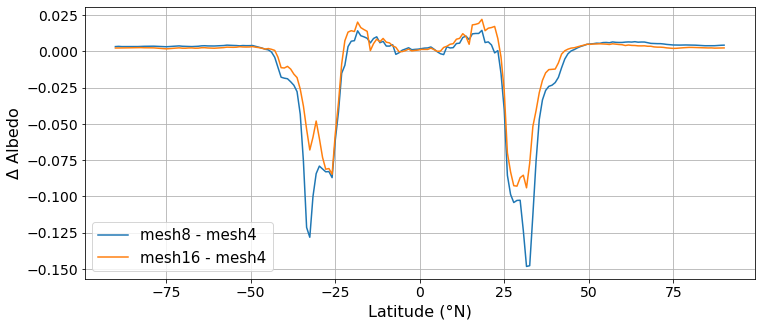

In [22]:
# Overall: shows the difference between patch sizes in zonally averaged albedo

plt.figure(figsize=(12,5))

# Calculates the reference
ds4 = ts_dict_atm['mesh4'].groupby('time.year').mean('time').mean('lon')
fsr = ds4['FSDS'].mean('year') - ds4['FSNS'].mean('year')
ref = fsr / ds4['FSDS'].mean('year')

for case in ['mesh8','mesh16'] :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time').mean('lon')

    # Finds the difference between the case's data and the reference's data
    fsr = ds_case['FSDS'].mean('year') - ds_case['FSNS'].mean('year')
    alb = fsr / ds_case['FSDS'].mean('year')
    mapdata = alb - ref
    
    plt.plot(mapdata.lat,mapdata,label=f'{case} - mesh4')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Δ Albedo',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)

plt.show()
plt.close()

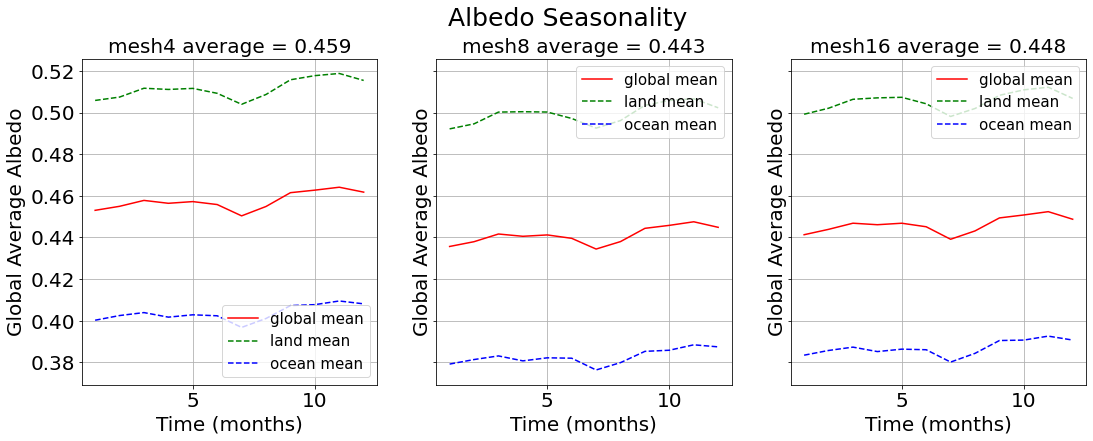

In [23]:
# Overall: plots separately the seasonality of albedo for all meshes

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

plt.suptitle('Albedo Seasonality',fontsize=25,y=1)

for i,case in enumerate(['mesh4','mesh8','mesh16']):

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.month').mean('time')

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
        
    # Weights the latitude
    weights = np.cos(np.deg2rad(ds_case.lat))
    weights.name = "weights"

    # Creates empty dictionaries to contain the global albedo, the land albedo, and the ocean albedo
    data_glo = []
    data_om = []
    data_lm = []
    for month,_ in enumerate(ds_case.month):

        # Finds the albedo for each month to show evolution
        fsr = ds_case['FSDS'].isel(month=month) - ds_case['FSNS'].isel(month=month)
        mapdata = fsr / ds_case['FSDS'].isel(month=month).where(ds_case['FSDS'].isel(month=month) != 0)

        # Calculates the global mean
        gm = mapdata.weighted(weights).mean(('lat', 'lon')).values
    
        # Defines a land timeseries where the land mask is present
        land = mapdata.where(mask == 1)
    
        # Defines an ocean timeseries where the land mask is not present (i.e. just ocean/water)
        ocean = mapdata.where(mask != 1)
    
        # Mean Land
        lm = land.weighted(weights).mean(('lat', 'lon')).values
    
        # Mean Ocean
        om = ocean.weighted(weights).mean(('lat', 'lon')).values

        data_glo.append(gm)
        data_om.append(om)
        data_lm.append(lm)

    # Calculates the average global albedo for all the year
    fsr = ds_case['FSDS'].mean('month') - ds_case['FSNS'].mean('month')
    mean_data = fsr / ds_case['FSDS'].mean('month')
    gm = mean_data.weighted(weights).mean(('lat', 'lon')).values

    axes[i].plot(ds_case.month,data_glo,'r',label='global mean')
    axes[i].plot(ds_case.month,data_lm,'g--',label='land mean')
    axes[i].plot(ds_case.month,data_om,'b--',label='ocean mean')
    
    axes[i].set_xlabel('Time (months)',fontsize=20)
    axes[i].set_ylabel('Global Average Albedo',fontsize=20)
    axes[i].tick_params(axis='both',labelsize=20)

    axes[i].grid()
    axes[i].legend(fontsize=15)

    axes[i].set_title(f'{case} average = {gm:.3f}',fontsize=20)

plt.show()
plt.close()